In [1]:
# Install if needed
# !pip install imbalanced-learn shap xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (classification_report, roc_auc_score,
                                         RocCurveDisplay, PrecisionRecallDisplay,
                                         confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling    import SMOTE
from imblearn.pipeline         import Pipeline as ImbPipeline
from xgboost                   import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('data/feature_matrix_segmented.csv')

c:\Users\risha\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Features to use for modelling ──
# Use RAW features (not log versions) — tree models handle skew natively
# Exclude leaky cols: last_purchase_day (directly defines churn label)
MODEL_FEATURES = [
    'recency', 'frequency', 'monetary', 'avg_basket',
    'tenure_days', 'purchase_rate', 'active_days',
    'avg_items_per_basket', 'top_store_share', 'unique_stores_visited',
    'trips_morning', 'trips_afternoon', 'trips_evening',
    'coupons_redeemed', 'coupon_redemption_rate', 'was_targeted_by_campaign',
    'pct_spend_on_discount', 'private_label_ratio',
    'dept_diversity', 'commodity_diversity', 'unique_products',
    'return_rate',
]

# Cap the known outlier
cap = df['avg_items_per_basket'].quantile(0.99)
df['avg_items_per_basket'] = df['avg_items_per_basket'].clip(upper=cap)

X = df[MODEL_FEATURES]
y = df['churned']

# Stratified split — preserves 6.8% churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  churn={y_train.mean()*100:.1f}%")
print(f"Test : {X_test.shape}   |  churn={y_test.mean()*100:.1f}%")
print(f"\nChurn in test set : {y_test.sum()} positive cases")

Train: (1999, 22)  |  churn=6.9%
Test : (500, 22)   |  churn=6.8%

Churn in test set : 34 positive cases


In [3]:
# SMOTE is applied INSIDE the pipeline so it never touches the test set
lr_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42, k_neighbors=5)),
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    )),
])

lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_pred  = lr_pipe.predict(X_test)

print("=== Logistic Regression ===")
print(f"ROC-AUC : {roc_auc_score(y_test, lr_proba):.4f}")
print()
print(classification_report(y_test, lr_pred, target_names=['Retained', 'Churned']))

# 5-fold CV AUC on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

=== Logistic Regression ===
ROC-AUC : 0.8369

              precision    recall  f1-score   support

    Retained       0.97      0.76      0.85       466
     Churned       0.18      0.71      0.28        34

    accuracy                           0.75       500
   macro avg       0.57      0.73      0.57       500
weighted avg       0.92      0.75      0.81       500

CV ROC-AUC (5-fold): 0.8289 ± 0.0477


In [4]:
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )),
])

rf_pipe.fit(X_train, y_train)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]
rf_pred  = rf_pipe.predict(X_test)

print("=== Random Forest ===")
print(f"ROC-AUC : {roc_auc_score(y_test, rf_proba):.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=['Retained', 'Churned']))

cv_scores_rf = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC (5-fold): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

=== Random Forest ===
ROC-AUC : 0.8793

              precision    recall  f1-score   support

    Retained       0.97      0.85      0.90       466
     Churned       0.24      0.68      0.36        34

    accuracy                           0.83       500
   macro avg       0.61      0.76      0.63       500
weighted avg       0.92      0.83      0.87       500

CV ROC-AUC (5-fold): 0.8686 ± 0.0214


In [5]:
# XGBoost handles imbalance natively via scale_pos_weight
# scale_pos_weight = negatives / positives
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.1f}  (neg={neg}, pos={pos})")

xgb_model = XGBClassifier(
    n_estimators      = 400,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = spw,
    eval_metric       = 'auc',
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

xgb_model.fit(X_train, y_train)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_model.predict(X_test)

print("\n=== XGBoost ===")
print(f"ROC-AUC : {roc_auc_score(y_test, xgb_proba):.4f}")
print()
print(classification_report(y_test, xgb_pred, target_names=['Retained', 'Churned']))

cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC (5-fold): {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

scale_pos_weight = 13.6  (neg=1862, pos=137)

=== XGBoost ===
ROC-AUC : 0.8622

              precision    recall  f1-score   support

    Retained       0.95      0.94      0.95       466
     Churned       0.26      0.26      0.26        34

    accuracy                           0.90       500
   macro avg       0.60      0.60      0.60       500
weighted avg       0.90      0.90      0.90       500

CV ROC-AUC (5-fold): 0.8510 ± 0.0139


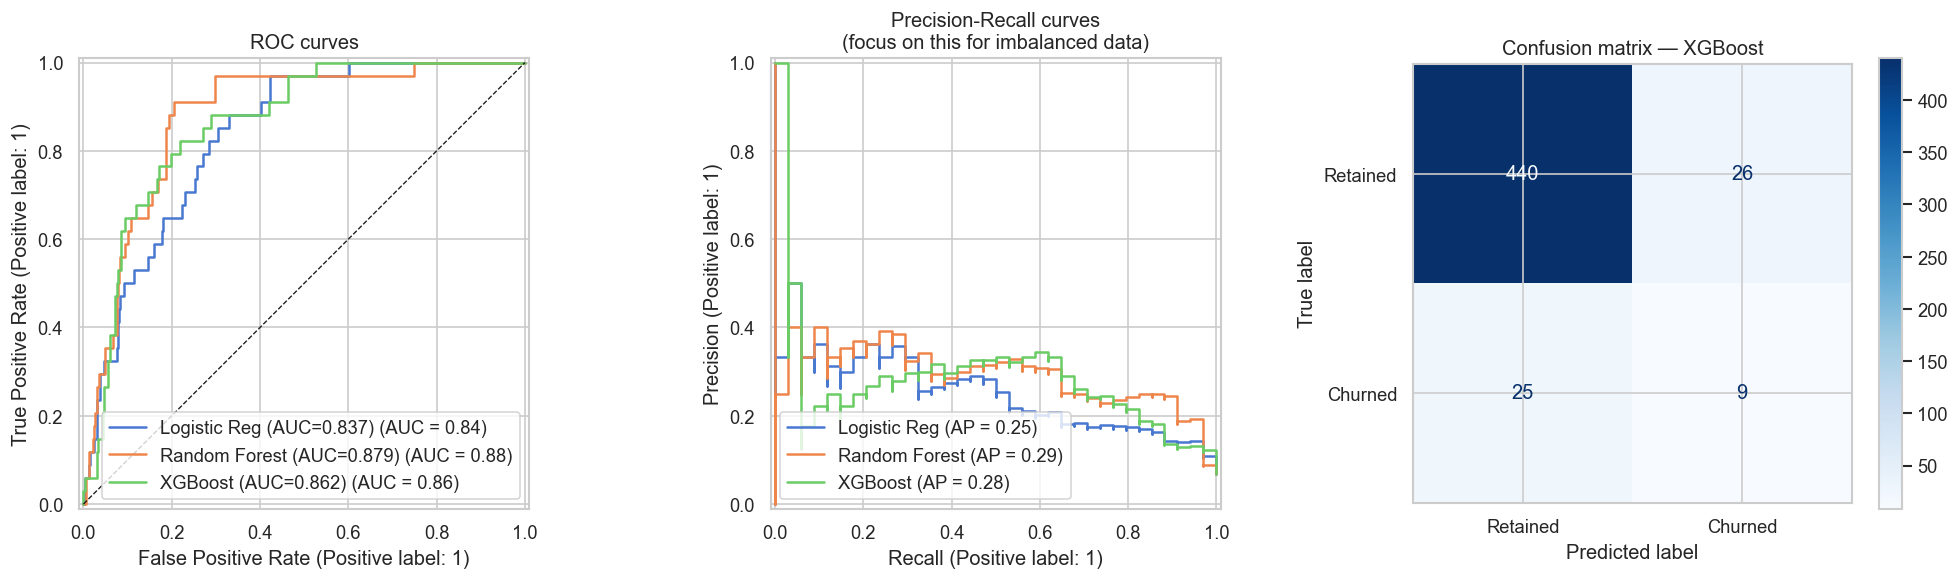

              Model  ROC-AUC  CV-AUC mean  CV-AUC std
Logistic Regression   0.8369       0.8289      0.0477
      Random Forest   0.8793       0.8686      0.0214
            XGBoost   0.8622       0.8510      0.0139


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── ROC curves ──
for name, proba in [('Logistic Reg', lr_proba),
                      ('Random Forest', rf_proba),
                      ('XGBoost', xgb_proba)]:
    RocCurveDisplay.from_predictions(
        y_test, proba, name=f"{name} (AUC={roc_auc_score(y_test,proba):.3f})",
        ax=axes[0]
    )
axes[0].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[0].set_title('ROC curves')

# ── Precision-Recall curves (better for imbalanced data) ──
for name, proba in [('Logistic Reg', lr_proba),
                      ('Random Forest', rf_proba),
                      ('XGBoost', xgb_proba)]:
    PrecisionRecallDisplay.from_predictions(
        y_test, proba, name=name, ax=axes[1]
    )
axes[1].set_title('Precision-Recall curves\n(focus on this for imbalanced data)')

# ── Confusion matrix for best model (XGBoost) ──
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_test, xgb_pred,
    display_labels=['Retained', 'Churned'],
    cmap='Blues', ax=axes[2]
)
axes[2].set_title('Confusion matrix — XGBoost')

plt.tight_layout()
plt.show()

# ── Summary table ──
summary = pd.DataFrame({
    'Model'     : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC'   : [round(roc_auc_score(y_test, p), 4) for p in [lr_proba, rf_proba, xgb_proba]],
    'CV-AUC mean': [round(s.mean(), 4) for s in [cv_scores, cv_scores_rf, cv_scores_xgb]],
    'CV-AUC std' : [round(s.std(), 4) for s in [cv_scores, cv_scores_rf, cv_scores_xgb]],
})
print(summary.to_string(index=False))

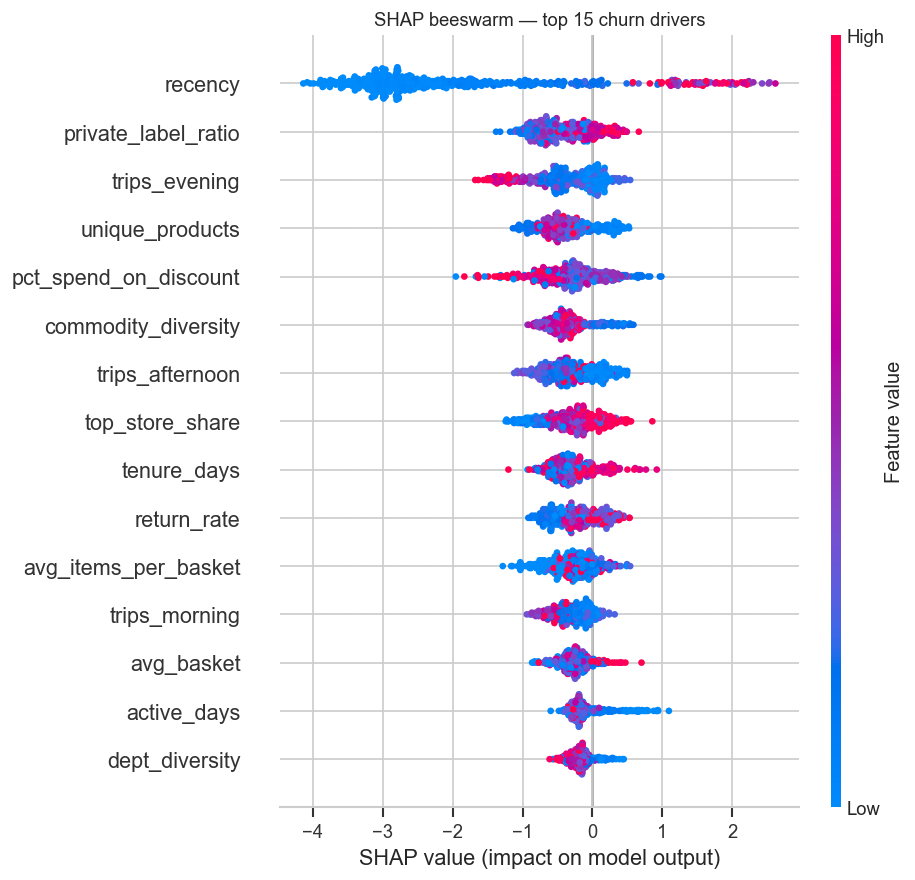

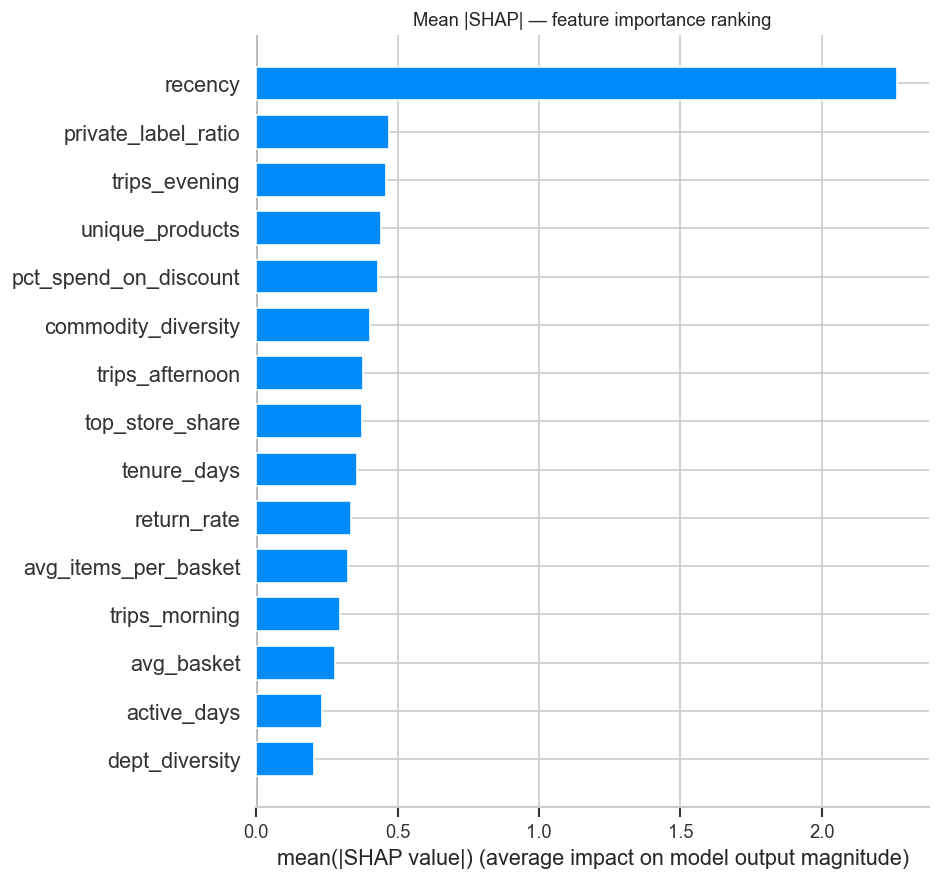

In [7]:
# SHAP explains WHY XGBoost makes each prediction
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# ── Beeswarm plot — global importance + direction ──
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='dot',
                   max_display=15, show=False)
plt.title('SHAP beeswarm — top 15 churn drivers', fontsize=11)
plt.tight_layout()
plt.show()

# ── Bar plot — mean absolute SHAP ──
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                   max_display=15, show=False)
plt.title('Mean |SHAP| — feature importance ranking', fontsize=11)
plt.tight_layout()
plt.show()

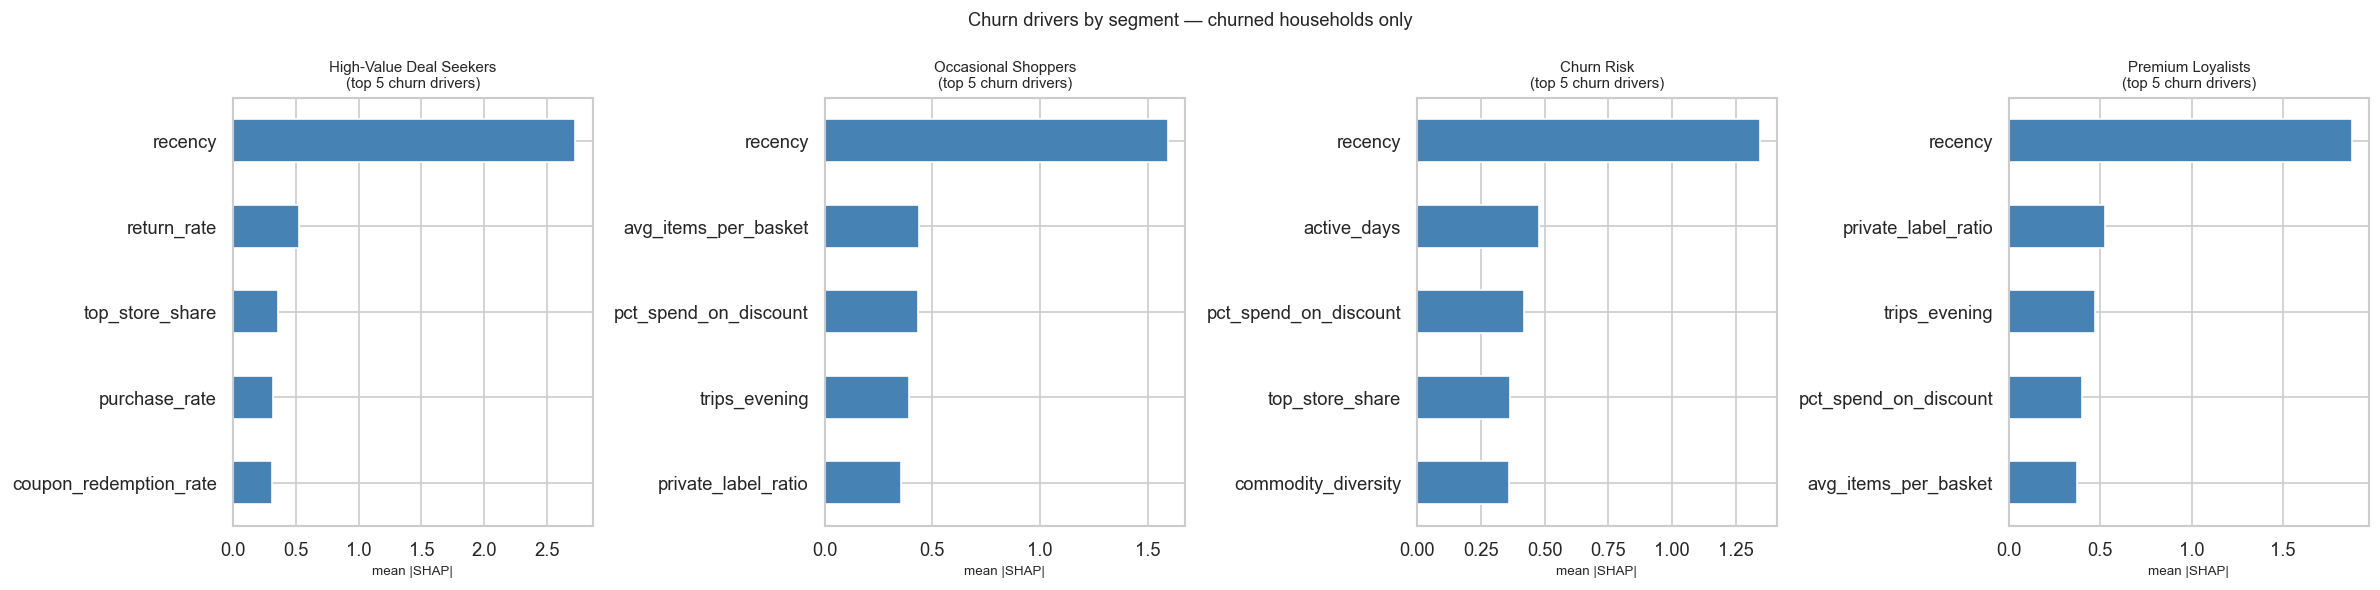

In [8]:
# Compute SHAP on full dataset (for segment-level analysis)
shap_all = explainer.shap_values(X)
shap_df  = pd.DataFrame(shap_all, columns=MODEL_FEATURES)
shap_df['segment_name'] = df['segment_name'].values
shap_df['churned']      = df['churned'].values

# Top 5 churn drivers per segment (mean |SHAP| among churned HHs)
TOP_N = 5
segments = df['segment_name'].unique()

fig, axes = plt.subplots(1, len(segments), figsize=(5*len(segments), 5),
                          sharey=False)

for i, seg in enumerate(segments):
    mask    = (shap_df['segment_name'] == seg) & (shap_df['churned'] == 1)
    seg_shap = shap_df.loc[mask, MODEL_FEATURES].abs().mean().nlargest(TOP_N)

    if len(seg_shap) == 0:
        axes[i].set_title(f'{seg}\n(no churned HHs in set)', fontsize=9)
        continue

    seg_shap.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{seg}\n(top {TOP_N} churn drivers)', fontsize=9)
    axes[i].set_xlabel('mean |SHAP|', fontsize=8)

fig.suptitle('Churn drivers by segment — churned households only', fontsize=11)
plt.tight_layout()
plt.show()

Churn risk tier distribution:
churn_risk_tier
Low       1610
Medium     497
High       392
Name: count, dtype: int64

Segment × Churn risk tier:

churn_risk_tier           Low  Medium  High  Total
segment_name                                      
Churn Risk                175     312   362    849
High-Value Deal Seekers    90       4     2     96
Occasional Shoppers       820     163    25   1008
Premium Loyalists         525      18     3    546
Total                    1610     497   392   2499


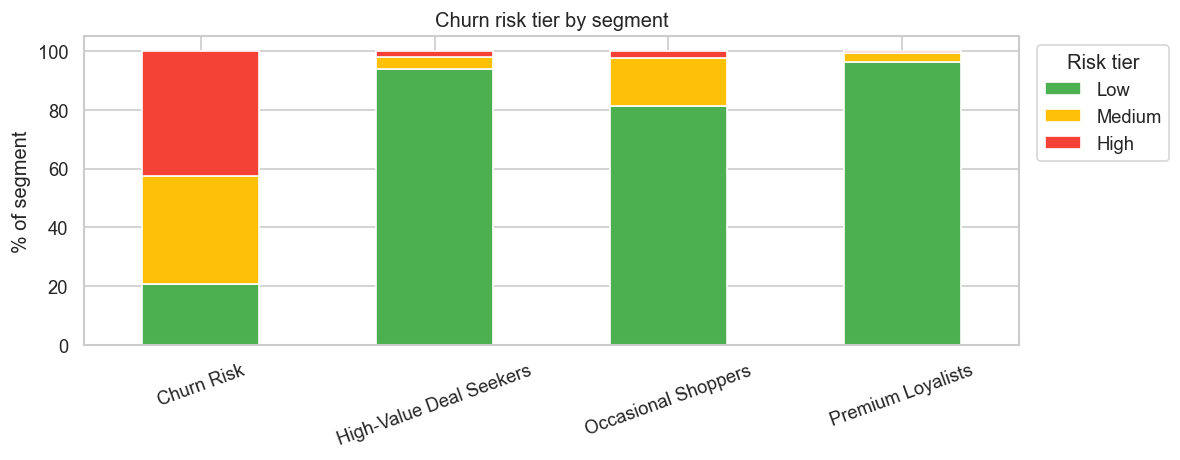

In [9]:
# Score all 2,499 households with churn probability
df['churn_proba'] = rf_pipe.predict_proba(X)[:, 1]

# Risk tier: Low / Medium / High
df['churn_risk_tier'] = pd.cut(
    df['churn_proba'],
    bins   = [0, 0.2, 0.5, 1.0],
    labels = ['Low', 'Medium', 'High']
)

print("Churn risk tier distribution:")
print(df['churn_risk_tier'].value_counts())
print()

# Cross-tab: segment × risk tier
ct = pd.crosstab(df['segment_name'], df['churn_risk_tier'],
                  margins=True, margins_name='Total')
print("Segment × Churn risk tier:\n")
print(ct.to_string())

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
ct_pct = pd.crosstab(df['segment_name'], df['churn_risk_tier'], normalize='index') * 100
ct_pct.plot(kind='bar', stacked=True, ax=ax,
            color=['#4CAF50', '#FFC107', '#F44336'], edgecolor='white')
ax.set_ylabel('% of segment')
ax.set_title('Churn risk tier by segment')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Risk tier', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

In [10]:
out_path = 'data/final_scored.csv'
df.to_csv(out_path, index=False)
print(f"✓ Saved → {out_path}")
print(f"  Shape        : {df.shape}")
print(f"  New columns  : churn_proba, churn_risk_tier")
print()

# Final summary for your README / project writeup
print("=== Phase 4 Summary ===")
print(f"Best model      : Random Forest")
print(f"Test ROC-AUC    : {roc_auc_score(y_test, rf_proba):.4f}")
print(f"CV ROC-AUC      : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
print(f"Class imbalance : handled via scale_pos_weight={spw:.1f}")
print()
print("High-risk households by segment:")
high_risk = df[df['churn_risk_tier'] == 'High']
print(high_risk['segment_name'].value_counts().to_string())
print("\n✓ Phase 4 complete. Ready for Phase 5 (Retention Strategy).")

✓ Saved → data/final_scored.csv
  Shape        : (2499, 46)
  New columns  : churn_proba, churn_risk_tier

=== Phase 4 Summary ===
Best model      : Random Forest
Test ROC-AUC    : 0.8793
CV ROC-AUC      : 0.8686 ± 0.0214
Class imbalance : handled via scale_pos_weight=13.6

High-risk households by segment:
segment_name
Churn Risk                 362
Occasional Shoppers         25
Premium Loyalists            3
High-Value Deal Seekers      2

✓ Phase 4 complete. Ready for Phase 5 (Retention Strategy).
